# 🧠 Enhanced 2D CNN Gunshot Detector (Mel-Spectrogram + Dual-Head)

> **Architectural & Hardware Enhancements:**
> - **Mel-Spectrogram Feature Extraction**: 64-band Log Mel-Spectrogram input preserving frequency transients and attack bursts across varying acoustic channels.
> - **Dual-Head Output Architecture**: Head 1 for Gunshot Detection (Sigmoid) + Head 2 for Impulse/Anomaly Detection (Sigmoid)
> - **Compound Audio Augmentations**: MixUp (Zhang et al. 2018), SpecAugment Frequency & Time Masking (Park et al. 2019), Pitch Shifting (Salamon & Bello 2017), and Speed Perturbation (Ko et al. 2015)
> - **NVIDIA GPU Acceleration (PyTorch/CUDA Backend)**: Utilizes NVIDIA RTX GPU with fast CUDA hardware acceleration via Keras 3 PyTorch backend
> - **Zero-Leakage Dataset Splitting & 1:1 Evaluation**: Integrated with `SPLIT_DATASET_750MS` train/val/test structure with balanced test validation

### Paper References
1. Salamon & Bello (2017) — "Deep CNNs and Data Augmentation for Environmental Sound Classification", IEEE
2. Park et al. (2019) — "SpecAugment", Interspeech (Google)
3. Zhang et al. (2018) — "mixup: Beyond Empirical Risk Minimization", ICLR
4. Magee et al. (2019) — "Low Cost Gunshot Detection on Raspberry Pi", IEEE BigData
5. Ko et al. (2015) — "Audio Augmentation for Speech Recognition", Interspeech


In [3]:
# ============================================================
# CELL 1: Dependencies Installation
# ============================================================
# %pip install -q keras torch torchvision torchaudio librosa soundfile scikit-learn matplotlib seaborn tqdm ipywidgets


In [4]:
# ============================================================
# CELL 2: Imports & NVIDIA GPU Acceleration Setup
# ============================================================
import os
import sys
import re
import random
import json
import warnings
from datetime import datetime
from pathlib import Path

# Force Keras to use PyTorch CUDA backend for GPU acceleration on Windows
os.environ["KERAS_BACKEND"] = "torch"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import keras
from keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    fbeta_score, roc_curve
)

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

print("=" * 60)
print(f"Keras Version   : {keras.__version__}")
print(f"Keras Backend   : {keras.config.backend()}")
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🚀 Active GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Running on CPU (CUDA GPU not detected)")
print("=" * 60)
print("✅ Device environment successfully initialized.")


Keras Version   : 3.12.4
Keras Backend   : torch
PyTorch Version : 2.6.0+cu124
CUDA Available  : True
🚀 Active GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
✅ Device environment successfully initialized.


In [5]:
# ============================================================
# CELL 3: CONFIGURATION & DYNAMIC PATH RESOLUTION
# ============================================================

# --- Dynamic Workspace Path Resolution ---
current_dir = Path.cwd().resolve()
if (current_dir / "Data" / "SPLIT_DATASET_750MS").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "Data" / "SPLIT_DATASET_750MS").exists():
    PROJECT_ROOT = current_dir.parent
elif (current_dir.parent.parent / "Data" / "SPLIT_DATASET_750MS").exists():
    PROJECT_ROOT = current_dir.parent.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "Data" / "SPLIT_DATASET_750MS"

# --- Audio Parameters ---
SAMPLE_RATE = 22050
CLIP_DURATION_MS = 750  # Must match 750ms dataset window
TARGET_SAMPLES = int(SAMPLE_RATE * CLIP_DURATION_MS / 1000)  # 16,537 samples

# --- Mel-Spectrogram Parameters ---
N_MELS = 64           # Number of Mel frequency bands
N_FFT = 2048          # FFT analysis window size
HOP_LENGTH = 512      # Hop length between FFT frames
FMIN = 20             # Minimum frequency (Hz)
FMAX = 8000           # Maximum frequency (Hz)

# --- Training Parameters ---
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.15
TEST_SPLIT = 0.15

# --- Augmentation Flags ---
USE_AUGMENTATION = True
USE_MIXUP = True
MIXUP_ALPHA = 0.3
USE_FREQ_MASK = True   # SpecAugment frequency masking
USE_TIME_MASK = True   # SpecAugment time masking
USE_PITCH_SHIFT = True
USE_SPEED_PERTURB = True
USE_ONLY_CLEAN = True
SHUFFLE_DATA = True

# --- Output Directory ---
OUTPUT_DIR = PROJECT_ROOT / "Enhanced_Models" / "02_Enhanced_2D_CNN" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 65)
print("🧠 ENHANCED 2D CNN CONFIGURATION")
print("=" * 65)
print(f"Project Root     : {PROJECT_ROOT}")
print(f"Data Directory   : {DATA_DIR} (Exists: {DATA_DIR.exists()})")
print(f"Sample Rate      : {SAMPLE_RATE:,} Hz")
print(f"Clip Duration    : {CLIP_DURATION_MS}ms ({TARGET_SAMPLES:,} samples)")
print(f"Mel-Spectrogram  : {N_MELS} bands | FFT {N_FFT} | Hop {HOP_LENGTH} | [{FMIN}-{FMAX} Hz]")
print(f"Batch Size       : {BATCH_SIZE}")
print(f"Epochs           : {EPOCHS}")
print(f"Augmentations    : MixUp={USE_MIXUP}, FreqMask={USE_FREQ_MASK}, TimeMask={USE_TIME_MASK}, Pitch={USE_PITCH_SHIFT}, Speed={USE_SPEED_PERTURB}")
print(f"Output Directory : {OUTPUT_DIR}")
print("=" * 65)


🧠 ENHANCED 2D CNN CONFIGURATION
Project Root     : C:\Users\aadit\Desktop\Shoot_Catcher
Data Directory   : C:\Users\aadit\Desktop\Shoot_Catcher\Data\SPLIT_DATASET_750MS (Exists: True)
Sample Rate      : 22,050 Hz
Clip Duration    : 750ms (16,537 samples)
Mel-Spectrogram  : 64 bands | FFT 2048 | Hop 512 | [20-8000 Hz]
Batch Size       : 64
Epochs           : 50
Augmentations    : MixUp=True, FreqMask=True, TimeMask=True, Pitch=True, Speed=True
Output Directory : C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced_Models\02_Enhanced_2D_CNN\output


In [6]:
# ============================================================
# CELL 4: Audio Clip Loading & Source Grouping Helpers
# ============================================================

def load_audio_clip(filepath, sr=22050, target_samples=16537):
    """
    Fast, robust audio file loader using soundfile with librosa fallback.
    Returns zero-padded/trimmed normalized float32 waveform.
    """
    try:
        audio, file_sr = sf.read(str(filepath), dtype="float32")
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        if file_sr != sr:
            audio = librosa.resample(audio, orig_sr=file_sr, target_sr=sr)
        
        audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)
        
        if len(audio) >= target_samples:
            audio = audio[:target_samples]
        else:
            audio = np.pad(audio, (0, target_samples - len(audio)))
            
        peak = np.max(np.abs(audio))
        if peak > 1e-6:
            audio = audio / peak
        return audio.astype(np.float32)
    except Exception:
        try:
            audio, _ = librosa.load(str(filepath), sr=sr, mono=True)
            audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)
            if len(audio) >= target_samples:
                audio = audio[:target_samples]
            else:
                audio = np.pad(audio, (0, target_samples - len(audio)))
            peak = np.max(np.abs(audio))
            if peak > 1e-6:
                audio = audio / peak
            return audio.astype(np.float32)
        except Exception:
            return None


def extract_source_group(filename):
    """Extract original recording stem to prevent data leakage during splitting."""
    stem = Path(filename).stem
    no_prefix = re.sub(r"^c[01]_\d+_", "", stem)
    no_suffix = re.sub(r"_clip\d+.*$", "", no_prefix)
    no_aug = re.sub(r"_aug_\d+dB$", "", no_suffix)
    parts = re.split(r"_onset\d+|_win\d+|_clip\d+|_\d{6}$", no_aug)
    return parts[0] if parts else stem


def is_clean_file(filename):
    return "_aug_" not in Path(filename).stem


print("✅ Audio loader and grouping helper functions defined.")


✅ Audio loader and grouping helper functions defined.


In [7]:
# ============================================================
# CELL 5: Mel-Spectrogram Extraction & SpecAugment Pipeline
# ============================================================

def waveform_to_mel(y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX):
    """Convert raw waveform to normalized log-Mel-spectrogram [0.0, 1.0]."""
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=n_fft,
        hop_length=hop_length, fmin=fmin, fmax=fmax
    )
    S_dB = librosa.power_to_db(S, ref=np.max)
    S_norm = (S_dB + 80.0) / 80.0
    return np.clip(S_norm, 0.0, 1.0).astype(np.float32)


# --- Waveform Level Augmentations ---
def augment_waveform(y, sr):
    """Standard waveform perturbations: time shift, noise injection, gain scale."""
    aug = y.copy()
    if random.random() < 0.5:
        shift = int(len(aug) * random.uniform(-0.1, 0.1))
        aug = np.roll(aug, shift)
    if random.random() < 0.5:
        snr_db = random.uniform(15, 30)
        signal_power = np.mean(aug ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        aug = aug + np.random.normal(0, np.sqrt(max(noise_power, 1e-10)), len(aug)).astype(np.float32)
    if random.random() < 0.5:
        gain_db = random.uniform(-6, 6)
        aug = aug * (10 ** (gain_db / 20))
    peak = np.max(np.abs(aug))
    if peak > 1e-6:
        aug = aug / peak
    return aug.astype(np.float32)


def pitch_shift_aug(y, sr, max_semitones=2):
    """Pitch shifting to emulate caliber acoustic shifts."""
    try:
        n_steps = random.uniform(-max_semitones, max_semitones)
        shifted = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)
        peak = np.max(np.abs(shifted))
        return (shifted / peak if peak > 1e-6 else shifted).astype(np.float32)
    except Exception:
        return y


def speed_perturb_aug(y, target_len, max_rate=0.1):
    """Speed perturbation to emulate velocity dispersion."""
    try:
        rate = 1.0 + random.uniform(-max_rate, max_rate)
        stretched = librosa.effects.time_stretch(y=y, rate=rate)
        if len(stretched) >= target_len:
            stretched = stretched[:target_len]
        else:
            stretched = np.pad(stretched, (0, target_len - len(stretched)))
        peak = np.max(np.abs(stretched))
        return (stretched / peak if peak > 1e-6 else stretched).astype(np.float32)
    except Exception:
        return y


# --- SpecAugment (Park et al. 2019) ---
def specaugment_freq_mask(mel, max_bands=8):
    """Mask random contiguous frequency bands."""
    aug = mel.copy()
    n_bands = random.randint(1, max_bands)
    if mel.shape[0] > n_bands:
        start = random.randint(0, mel.shape[0] - n_bands)
        aug[start:start + n_bands, :] = 0.0
    return aug


def specaugment_time_mask(mel, max_frames=10):
    """Mask random contiguous time frames."""
    aug = mel.copy()
    n_frames = random.randint(1, max_frames)
    if mel.shape[1] > n_frames:
        start = random.randint(0, mel.shape[1] - n_frames)
        aug[:, start:start + n_frames] = 0.0
    return aug


# Verify Mel-Spectrogram shape
_test_mel = waveform_to_mel(np.zeros(TARGET_SAMPLES, dtype=np.float32), SAMPLE_RATE)
MEL_SHAPE = _test_mel.shape  # (N_MELS, time_frames)
INPUT_SHAPE_2D = MEL_SHAPE + (1,)  # (N_MELS, time_frames, 1)

print(f"✅ Mel-Spectrogram shape: {MEL_SHAPE} → 2D CNN Input Shape: {INPUT_SHAPE_2D}")


✅ Mel-Spectrogram shape: (64, 33) → 2D CNN Input Shape: (64, 33, 1)


In [8]:
# ============================================================
# CELL 6: Dataset Discovery, Splitting & Balancing
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

def collect_audio_from_dir(folder_path, use_clean_only=False):
    """Scans folder for class_0 and class_1 wav files with proper discrimination."""
    folder = Path(folder_path)
    files, labels, groups = [], [], []
    if not folder.exists():
        return files, labels, groups
    
    for sub in folder.iterdir():
        if not sub.is_dir():
            continue
        name = sub.name.lower()
        # Check class_0 / non-gunshot FIRST to prevent substring collision
        if "class_0" in name or "nongunshot" in name or "non_gunshot" in name or "background" in name or "noise" in name:
            label = 0
        elif "class_1" in name or "gunshot" in name or "gun" in name:
            label = 1
        else:
            continue
            
        for f in sorted(sub.glob("*.wav")):
            if use_clean_only and not is_clean_file(f.name):
                continue
            files.append(str(f))
            labels.append(label)
            groups.append(extract_source_group(f.name))
            
    return files, labels, groups


# Check if pre-split train/val/test folders exist
has_presplit = (DATA_DIR / "train").exists() and (DATA_DIR / "val").exists() and (DATA_DIR / "test").exists()

if has_presplit:
    print(f"📂 Detected pre-split dataset in {DATA_DIR}")
    train_files, train_labels, _ = collect_audio_from_dir(DATA_DIR / "train", use_clean_only=False)
    val_files, val_labels, _ = collect_audio_from_dir(DATA_DIR / "val", use_clean_only=False)
    test_files, test_labels, _ = collect_audio_from_dir(DATA_DIR / "test", use_clean_only=False)
else:
    print(f"📂 Scanning flat dataset directory: {DATA_DIR}")
    all_files, all_labels, all_groups = collect_audio_from_dir(DATA_DIR, use_clean_only=USE_ONLY_CLEAN)
    
    if len(all_files) == 0:
        raise FileNotFoundError(f"❌ No audio files found in {DATA_DIR}. Please check the path!")
        
    gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=42)
    remain_idx, test_idx = next(gss_test.split(all_files, all_labels, all_groups))

    remain_files = [all_files[i] for i in remain_idx]
    remain_labels = [all_labels[i] for i in remain_idx]
    remain_groups = [all_groups[i] for i in remain_idx]

    test_files = [all_files[i] for i in test_idx]
    test_labels = [all_labels[i] for i in test_idx]

    gss_val = GroupShuffleSplit(n_splits=1, test_size=VALIDATION_SPLIT / (1.0 - TEST_SPLIT), random_state=42)
    train_idx, val_idx = next(gss_val.split(remain_files, remain_labels, remain_groups))
    train_files = [remain_files[i] for i in train_idx]
    train_labels = [remain_labels[i] for i in train_idx]
    val_files = [remain_files[i] for i in val_idx]
    val_labels = [remain_labels[i] for i in val_idx]

# --- 1:1 Balancing helper for Evaluation sets ---
def balance_1to1(f_list, l_list):
    arr_f = np.array(f_list)
    arr_l = np.array(l_list)
    pos_idx = np.where(arr_l == 1)[0]
    neg_idx = np.where(arr_l == 0)[0]
    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return f_list, l_list
    min_cnt = min(len(pos_idx), len(neg_idx))
    sel_pos = np.random.choice(pos_idx, min_cnt, replace=False)
    sel_neg = np.random.choice(neg_idx, min_cnt, replace=False)
    final_idx = np.concatenate([sel_pos, sel_neg])
    np.random.shuffle(final_idx)
    return arr_f[final_idx].tolist(), arr_l[final_idx].tolist()

val_files, val_labels = balance_1to1(val_files, val_labels)
test_files, test_labels = balance_1to1(test_files, test_labels)

if SHUFFLE_DATA:
    c = list(zip(train_files, train_labels))
    random.shuffle(c)
    train_files, train_labels = zip(*c)
    train_files, train_labels = list(train_files), list(train_labels)

print("\n" + "=" * 60)
print("📊 DATA SPLIT SUMMARY (Zero-Leakage & 1:1 Evaluation)")
print("=" * 60)
for name, f_list, l_list in [("TRAIN", train_files, train_labels), ("VAL", val_files, val_labels), ("TEST", test_files, test_labels)]:
    arr = np.array(l_list)
    print(f" {name:5s}: {len(f_list):>6,} files | 🔫 Gunshots: {int(np.sum(arr==1)):>5,} | 🎵 Non-gunshots: {int(np.sum(arr==0)):>5,}")
print("=" * 60)


📂 Detected pre-split dataset in C:\Users\aadit\Desktop\Shoot_Catcher\Data\SPLIT_DATASET_750MS

📊 DATA SPLIT SUMMARY (Zero-Leakage & 1:1 Evaluation)
 TRAIN: 41,779 files | 🔫 Gunshots: 3,069 | 🎵 Non-gunshots: 38,710
 VAL  :  1,420 files | 🔫 Gunshots:   710 | 🎵 Non-gunshots:   710
 TEST :  1,442 files | 🔫 Gunshots:   721 | 🎵 Non-gunshots:   721


In [9]:
# ============================================================
# CELL 7: Load Audio Waveforms and Convert to Mel-Spectrograms
# ============================================================

def load_mel_dataset(file_list, label_list, sr=SAMPLE_RATE, target_samples=TARGET_SAMPLES, augment=False):
    X, y = [], []
    failed = 0
    for filepath, label in tqdm(zip(file_list, label_list), total=len(file_list), desc="Extracting Mel-Spectrograms"):
        clip = load_audio_clip(filepath, sr, target_samples)
        if clip is None:
            failed += 1
            continue
            
        mel = waveform_to_mel(clip, sr)
        X.append(mel)
        y.append(label)
        
        if augment and USE_AUGMENTATION:
            # 1. Waveform perturbations
            aug_clip = augment_waveform(clip, sr)
            if USE_PITCH_SHIFT and random.random() < 0.3:
                aug_clip = pitch_shift_aug(aug_clip, sr)
            if USE_SPEED_PERTURB and random.random() < 0.3:
                aug_clip = speed_perturb_aug(aug_clip, target_samples)
                
            # 2. Convert to Mel
            aug_mel = waveform_to_mel(aug_clip, sr)
            
            # 3. SpecAugment masking
            if USE_FREQ_MASK and random.random() < 0.4:
                aug_mel = specaugment_freq_mask(aug_mel)
            if USE_TIME_MASK and random.random() < 0.4:
                aug_mel = specaugment_time_mask(aug_mel)
                
            X.append(aug_mel)
            y.append(label)
            
    if failed > 0:
        print(f"  ⚠️ {failed} files failed to load and were skipped.")
        
    X = np.array(X, dtype=np.float32)[..., np.newaxis]  # (N, n_mels, time_frames, 1)
    y = np.array(y, dtype=np.float32)
    return X, y

print("📥 Loading & Transforming TRAINING set (with compound augmentations)...")
X_train, y_train = load_mel_dataset(train_files, train_labels, augment=True)

print("📥 Loading & Transforming VALIDATION set (clean)...")
X_val, y_val = load_mel_dataset(val_files, val_labels, augment=False)

print("📥 Loading & Transforming TEST set (clean)...")
X_test, y_test = load_mel_dataset(test_files, test_labels, augment=False)

print(f"\n📦 Array Dimensions: X_train={X_train.shape} | X_val={X_val.shape} | X_test={X_test.shape}")


📥 Loading & Transforming TRAINING set (with compound augmentations)...


Extracting Mel-Spectrograms:   0%|          | 0/41779 [00:00<?, ?it/s]

📥 Loading & Transforming VALIDATION set (clean)...


Extracting Mel-Spectrograms:   0%|          | 0/1420 [00:00<?, ?it/s]

📥 Loading & Transforming TEST set (clean)...


Extracting Mel-Spectrograms:   0%|          | 0/1442 [00:00<?, ?it/s]


📦 Array Dimensions: X_train=(83558, 64, 33, 1) | X_val=(1420, 64, 33, 1) | X_test=(1442, 64, 33, 1)


In [10]:
# ============================================================
# CELL 8: 2D MixUp Batch Generator for GPU Training
# Ref: Zhang et al. (2018) "mixup: Beyond Empirical Risk Minimization"
# ============================================================

def mixup_generator(X, y, batch_size, class_weights, alpha=MIXUP_ALPHA):
    """Yields batches of 2D MixUp-augmented Mel-Spectrograms for dual-head training."""
    indices = np.arange(len(X))
    cw0 = float(class_weights.get(0, 1.0))
    cw1 = float(class_weights.get(1, 1.0))
    
    while True:
        np.random.shuffle(indices)
        for i in range(0, len(X), batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X[batch_idx].copy()
            y_batch = y[batch_idx].copy()
            
            if USE_MIXUP and len(X_batch) > 1:
                lam = np.random.beta(alpha, alpha, size=len(X_batch)).astype(np.float32)
                lam_x = lam.reshape(-1, 1, 1, 1)
                
                mix_idx = np.random.permutation(len(X_batch))
                X_batch = lam_x * X_batch + (1.0 - lam_x) * X_batch[mix_idx]
                y_batch = lam * y_batch + (1.0 - lam) * y_batch[mix_idx]
                
            s_weights = (y_batch * cw1 + (1.0 - y_batch) * cw0).astype(np.float32)
            y_target = y_batch.astype(np.float32)
            
            yield (
                X_batch.astype(np.float32),
                {"gunshot_output": y_target, "anomaly_output": y_target},
                {"gunshot_output": s_weights, "anomaly_output": np.ones_like(y_target, dtype=np.float32)}
            )

print("✅ GPU-ready 2D MixUp generator defined.")


✅ GPU-ready 2D MixUp generator defined.


In [11]:
# ============================================================
# CELL 9: DUAL-HEAD 2D CNN Architecture & Compilation
# ============================================================

def build_enhanced_2d_cnn(input_shape):
    """
    Enhanced 2D CNN Gunshot Detector with Mel-Spectrogram input & Dual-Head Output:
    - Backbone: 4 Conv2D + BatchNorm + MaxPooling2D layers + GlobalAveragePooling2D
    - Head 1: Gunshot Probability (Primary Detector)
    - Head 2: Anomaly / Novelty Score (Secondary Detector)
    """
    inputs = layers.Input(shape=input_shape, name="mel_input")
    
    # Layer 1
    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)
    
    # Layer 2
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)
    
    # Layer 3
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.MaxPooling2D((2, 2), name="pool3")(x)
    
    # Layer 4
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="conv4")(x)
    x = layers.BatchNormalization(name="bn4")(x)
    
    shared_features = layers.GlobalAveragePooling2D(name="gap")(x)
    
    # Head 1: Gunshot Detection
    h1 = layers.Dense(64, activation="relu", name="gunshot_dense")(shared_features)
    h1 = layers.Dropout(0.4, name="gunshot_dropout")(h1)
    gunshot_output = layers.Dense(1, activation="sigmoid", name="gunshot_output")(h1)
    
    # Head 2: Anomaly Detection
    h2 = layers.Dense(32, activation="relu", name="anomaly_dense")(shared_features)
    h2 = layers.Dropout(0.3, name="anomaly_dropout")(h2)
    anomaly_output = layers.Dense(1, activation="sigmoid", name="anomaly_output")(h2)
    
    model = models.Model(
        inputs=inputs,
        outputs={"gunshot_output": gunshot_output, "anomaly_output": anomaly_output},
        name="Enhanced_2D_CNN_DualHead"
    )
    return model


input_shape_2d = X_train.shape[1:]
model = build_enhanced_2d_cnn(input_shape_2d)

# --- Class weights ---
class_weights_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights_arr)}
print(f"⚖️ Computed Balanced Class Weights: {class_weight_dict}")

# --- Compile with Dual Loss Functions ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "gunshot_output": "binary_crossentropy",
        "anomaly_output": "binary_crossentropy",
    },
    loss_weights={"gunshot_output": 1.0, "anomaly_output": 0.3},
    metrics={
        "gunshot_output": [
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
        "anomaly_output": ["accuracy"],
    },
)

model.summary()
print(f"\n📊 Total Trainable Parameters: {model.count_params():,}")


⚖️ Computed Balanced Class Weights: {0: 0.5396409196590028, 1: 6.806614532420984}


Model: "Enhanced_2D_CNN_DualHead"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_input           │ (None, 64, 33, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 64, 33,    │        160 │ mel_input[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 64, 33,    │         64 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 16,    │          0 │ bn1[0][0]         │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 32, 16,    │      4,640 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 32, 16,    │        128 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 16, 8, 32) │          0 │ bn2[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 16, 8, 64) │     18,496 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 16, 8, 64) │        256 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 8, 4, 64)  │          0 │ bn3[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 8, 4, 128) │     73,856 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 8, 4, 128) │        512 │ conv4[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ bn4[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_dense       │ (None, 32)        │      4,128 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_dense       │ (None, 64)        │      8,256 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_dropout     │ (None, 32)        │          0 │ anomaly_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_dropout     │ (None, 64)        │          0 │ gunshot_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 110,594 (432.01 KB)

 Trainable params: 110,114 (430.13 KB)

 Non-trainable params: 480 (1.88 KB)


📊 Total Trainable Parameters: 110,594



🚀 Starting training for 50 epochs (1306 steps/epoch) on GPU...
Epoch 1/50
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - anomaly_output_accuracy: 0.8461 - anomaly_output_loss: 0.1781 - gunshot_output_accuracy: 0.7974 - gunshot_output_auc: 0.7658 - gunshot_output_loss: 0.3626 - gunshot_output_precision: 0.5299 - gunshot_output_recall: 0.5073 - loss: 0.4160
Epoch 1: val_gunshot_output_auc improved from None to 0.99554, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced_Models\02_Enhanced_2D_CNN\output\enhanced_2d_cnn_best.h5


1306/1306 ━━━━━━━━━━━━━━━━━━━━ 57s 43ms/step - anomaly_output_accuracy: 0.8555 - anomaly_output_loss: 0.1318 - gunshot_output_accuracy: 0.8208 - gunshot_output_auc: 0.7880 - gunshot_output_loss: 0.3159 - gunshot_output_precision: 0.6202 - gunshot_output_recall: 0.5207 - loss: 0.3554 - val_anomaly_output_accuracy: 0.9711 - val_anomaly_output_loss: 0.1072 - val_gunshot_output_accuracy: 0.9732 - val_gunshot_output_auc: 0.9955 - val_gunshot_output_loss: 0.1025 - val_gunshot_output_precision: 0.9578 - val_gunshot_output_recall: 0.9901 - val_loss: 0.1347 - learning_rate: 0.0010
Epoch 2/50
1305/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - anomaly_output_accuracy: 0.8598 - anomaly_output_loss: 0.1051 - gunshot_output_accuracy: 0.8375 - gunshot_output_auc: 0.8067 - gunshot_output_loss: 0.2710 - gunshot_output_precision: 0.7207 - gunshot_output_recall: 0.5302 - loss: 0.3026
Epoch 2: val_gunshot_output_auc improved from 0.99554 to 0.99804, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced

1306/1306 ━━━━━━━━━━━━━━━━━━━━ 52s 39ms/step - anomaly_output_accuracy: 0.8599 - anomaly_output_loss: 0.1018 - gunshot_output_accuracy: 0.8399 - gunshot_output_auc: 0.8060 - gunshot_output_loss: 0.2657 - gunshot_output_precision: 0.7407 - gunshot_output_recall: 0.5254 - loss: 0.2963 - val_anomaly_output_accuracy: 0.8197 - val_anomaly_output_loss: 0.3879 - val_gunshot_output_accuracy: 0.9507 - val_gunshot_output_auc: 0.9980 - val_gunshot_output_loss: 0.1991 - val_gunshot_output_precision: 0.9969 - val_gunshot_output_recall: 0.9042 - val_loss: 0.3154 - learning_rate: 0.0010
Epoch 3/50
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - anomaly_output_accuracy: 0.8596 - anomaly_output_loss: 0.0941 - gunshot_output_accuracy: 0.8433 - gunshot_output_auc: 0.8147 - gunshot_output_loss: 0.2530 - gunshot_output_precision: 0.7823 - gunshot_output_recall: 0.5344 - loss: 0.2812
Epoch 3: val_gunshot_output_auc did not improve from 0.99804
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 51s 39ms/step - anomaly_output_accu

1306/1306 ━━━━━━━━━━━━━━━━━━━━ 51s 39ms/step - anomaly_output_accuracy: 0.8634 - anomaly_output_loss: 0.0797 - gunshot_output_accuracy: 0.8541 - gunshot_output_auc: 0.8173 - gunshot_output_loss: 0.2182 - gunshot_output_precision: 0.8586 - gunshot_output_recall: 0.5229 - loss: 0.2421 - val_anomaly_output_accuracy: 0.9754 - val_anomaly_output_loss: 0.0550 - val_gunshot_output_accuracy: 0.9641 - val_gunshot_output_auc: 0.9983 - val_gunshot_output_loss: 0.0895 - val_gunshot_output_precision: 0.9341 - val_gunshot_output_recall: 0.9986 - val_loss: 0.1060 - learning_rate: 0.0010
Epoch 7/50
1305/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - anomaly_output_accuracy: 0.8641 - anomaly_output_loss: 0.0786 - gunshot_output_accuracy: 0.8541 - gunshot_output_auc: 0.8209 - gunshot_output_loss: 0.2165 - gunshot_output_precision: 0.8497 - gunshot_output_recall: 0.5246 - loss: 0.2401
Epoch 7: val_gunshot_output_auc did not improve from 0.99830
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 51s 39ms/step - anomaly_output_accu

1306/1306 ━━━━━━━━━━━━━━━━━━━━ 50s 38ms/step - anomaly_output_accuracy: 0.8647 - anomaly_output_loss: 0.0740 - gunshot_output_accuracy: 0.8578 - gunshot_output_auc: 0.8226 - gunshot_output_loss: 0.2094 - gunshot_output_precision: 0.8914 - gunshot_output_recall: 0.5317 - loss: 0.2316 - val_anomaly_output_accuracy: 0.9831 - val_anomaly_output_loss: 0.0774 - val_gunshot_output_accuracy: 0.9894 - val_gunshot_output_auc: 0.9987 - val_gunshot_output_loss: 0.0663 - val_gunshot_output_precision: 0.9943 - val_gunshot_output_recall: 0.9845 - val_loss: 0.0895 - learning_rate: 0.0010
Epoch 10/50
1305/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - anomaly_output_accuracy: 0.8635 - anomaly_output_loss: 0.0734 - gunshot_output_accuracy: 0.8561 - gunshot_output_auc: 0.8231 - gunshot_output_loss: 0.2098 - gunshot_output_precision: 0.8872 - gunshot_output_recall: 0.5325 - loss: 0.2318
Epoch 10: val_gunshot_output_auc improved from 0.99869 to 0.99939, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\Enhanc

1306/1306 ━━━━━━━━━━━━━━━━━━━━ 54s 41ms/step - anomaly_output_accuracy: 0.8640 - anomaly_output_loss: 0.0738 - gunshot_output_accuracy: 0.8564 - gunshot_output_auc: 0.8227 - gunshot_output_loss: 0.2081 - gunshot_output_precision: 0.8833 - gunshot_output_recall: 0.5262 - loss: 0.2303 - val_anomaly_output_accuracy: 0.9761 - val_anomaly_output_loss: 0.0709 - val_gunshot_output_accuracy: 0.9894 - val_gunshot_output_auc: 0.9994 - val_gunshot_output_loss: 0.0461 - val_gunshot_output_precision: 0.9971 - val_gunshot_output_recall: 0.9817 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 11/50
1305/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - anomaly_output_accuracy: 0.8648 - anomaly_output_loss: 0.0736 - gunshot_output_accuracy: 0.8578 - gunshot_output_auc: 0.8247 - gunshot_output_loss: 0.2045 - gunshot_output_precision: 0.8904 - gunshot_output_recall: 0.5330 - loss: 0.2266
Epoch 11: val_gunshot_output_auc did not improve from 0.99939
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 52s 39ms/step - anomaly_output_ac

1306/1306 ━━━━━━━━━━━━━━━━━━━━ 50s 38ms/step - anomaly_output_accuracy: 0.8645 - anomaly_output_loss: 0.0708 - gunshot_output_accuracy: 0.8595 - gunshot_output_auc: 0.8285 - gunshot_output_loss: 0.2002 - gunshot_output_precision: 0.9172 - gunshot_output_recall: 0.5232 - loss: 0.2215 - val_anomaly_output_accuracy: 0.9965 - val_anomaly_output_loss: 0.0317 - val_gunshot_output_accuracy: 0.9634 - val_gunshot_output_auc: 0.9999 - val_gunshot_output_loss: 0.0892 - val_gunshot_output_precision: 0.9318 - val_gunshot_output_recall: 1.0000 - val_loss: 0.0987 - learning_rate: 0.0010
Epoch 14/50
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - anomaly_output_accuracy: 0.8631 - anomaly_output_loss: 0.0694 - gunshot_output_accuracy: 0.8582 - gunshot_output_auc: 0.8238 - gunshot_output_loss: 0.1981 - gunshot_output_precision: 0.9198 - gunshot_output_recall: 0.5178 - loss: 0.2189
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: val_gunshot_output_auc did not improve

1306/1306 ━━━━━━━━━━━━━━━━━━━━ 50s 38ms/step - anomaly_output_accuracy: 0.8658 - anomaly_output_loss: 0.0645 - gunshot_output_accuracy: 0.8625 - gunshot_output_auc: 0.8291 - gunshot_output_loss: 0.1865 - gunshot_output_precision: 0.9451 - gunshot_output_recall: 0.5291 - loss: 0.2058 - val_anomaly_output_accuracy: 0.9979 - val_anomaly_output_loss: 0.0198 - val_gunshot_output_accuracy: 0.9951 - val_gunshot_output_auc: 0.9999 - val_gunshot_output_loss: 0.0267 - val_gunshot_output_precision: 0.9916 - val_gunshot_output_recall: 0.9986 - val_loss: 0.0326 - learning_rate: 5.0000e-04
Epoch 17/50
1305/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - anomaly_output_accuracy: 0.8665 - anomaly_output_loss: 0.0661 - gunshot_output_accuracy: 0.8637 - gunshot_output_auc: 0.8325 - gunshot_output_loss: 0.1922 - gunshot_output_precision: 0.9533 - gunshot_output_recall: 0.5246 - loss: 0.2120
Epoch 17: val_gunshot_output_auc improved from 0.99987 to 0.99993, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\En

1306/1306 ━━━━━━━━━━━━━━━━━━━━ 50s 38ms/step - anomaly_output_accuracy: 0.8654 - anomaly_output_loss: 0.0659 - gunshot_output_accuracy: 0.8627 - gunshot_output_auc: 0.8344 - gunshot_output_loss: 0.1928 - gunshot_output_precision: 0.9531 - gunshot_output_recall: 0.5311 - loss: 0.2126 - val_anomaly_output_accuracy: 0.9958 - val_anomaly_output_loss: 0.0294 - val_gunshot_output_accuracy: 0.9979 - val_gunshot_output_auc: 0.9999 - val_gunshot_output_loss: 0.0310 - val_gunshot_output_precision: 0.9972 - val_gunshot_output_recall: 0.9986 - val_loss: 0.0398 - learning_rate: 5.0000e-04
Epoch 18/50
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - anomaly_output_accuracy: 0.8666 - anomaly_output_loss: 0.0627 - gunshot_output_accuracy: 0.8642 - gunshot_output_auc: 0.8293 - gunshot_output_loss: 0.1836 - gunshot_output_precision: 0.9578 - gunshot_output_recall: 0.5269 - loss: 0.2024
Epoch 18: val_gunshot_output_auc did not improve from 0.99993
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 50s 38ms/step - anomaly_outpu

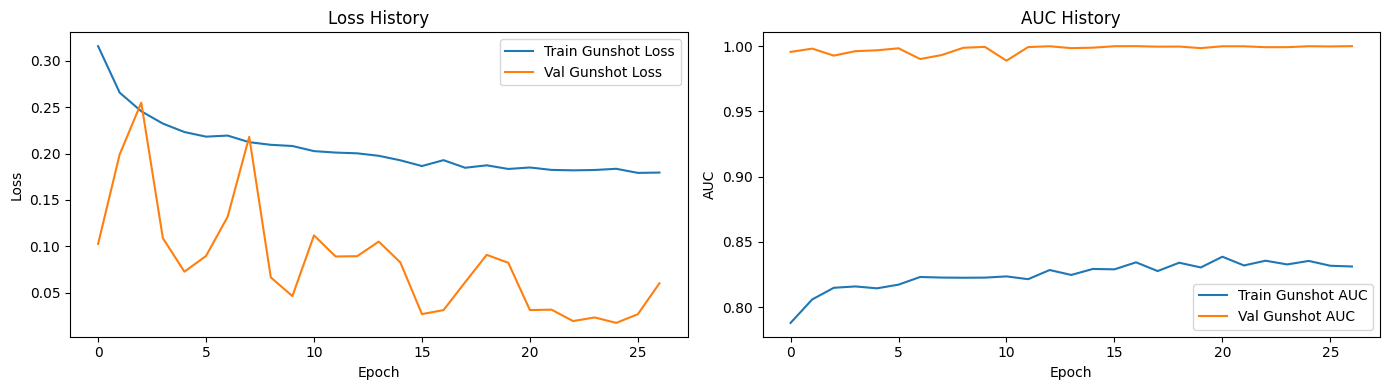


✅ Training complete! Best model saved to: C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced_Models\02_Enhanced_2D_CNN\output\enhanced_2d_cnn_best.h5


In [12]:
# ============================================================
# CELL 10: Training (GPU-Accelerated)
# ============================================================

best_model_path = OUTPUT_DIR / "enhanced_2d_cnn_best.h5"

callbacks_list = [
    callbacks.EarlyStopping(
        monitor="val_gunshot_output_auc", patience=10, mode="max",
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_gunshot_output_loss", factor=0.5, patience=4,
        min_lr=1e-6, verbose=1, mode="min"
    ),
    callbacks.ModelCheckpoint(
        str(best_model_path),
        monitor="val_gunshot_output_auc", mode="max",
        save_best_only=True, verbose=1
    )
]

train_gen = mixup_generator(X_train, y_train, BATCH_SIZE, class_weight_dict)
steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))

print(f"\n🚀 Starting training for {EPOCHS} epochs ({steps_per_epoch} steps/epoch) on GPU...")
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=(
        X_val,
        {"gunshot_output": y_val, "anomaly_output": y_val}
    ),
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["gunshot_output_loss"], label="Train Gunshot Loss")
axes[0].plot(history.history["val_gunshot_output_loss"], label="Val Gunshot Loss")
axes[0].set_title("Loss History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["gunshot_output_auc"], label="Train Gunshot AUC")
axes[1].plot(history.history["val_gunshot_output_auc"], label="Val Gunshot AUC")
axes[1].set_title("AUC History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "enhanced_2d_cnn_training_history.png", dpi=150)
plt.show()

print(f"\n✅ Training complete! Best model saved to: {best_model_path}")



📊 TEST CLASSIFICATION REPORT (Gunshot Head):
              precision    recall  f1-score   support

  Background       1.00      0.99      1.00       721
     Gunshot       0.99      1.00      1.00       721

    accuracy                           1.00      1442
   macro avg       1.00      1.00      1.00      1442
weighted avg       1.00      1.00      1.00      1442



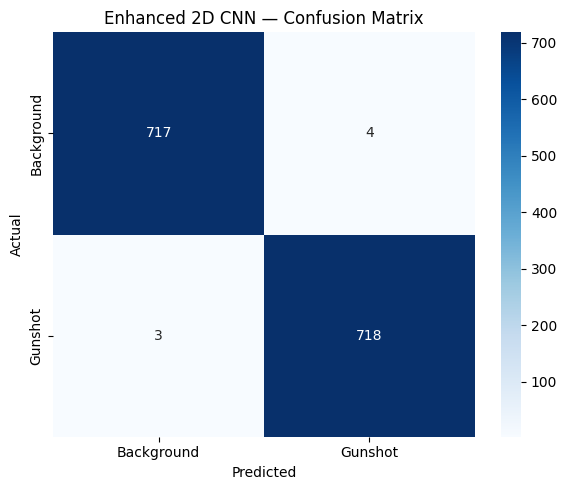


🎯 F2-Score (High Recall Optimization): 0.9956
🎯 ROC-AUC:                            0.9996
🎯 Average Precision (PR-AUC):         0.9996

💾 Evaluation metrics saved to: C:\Users\aadit\Desktop\Shoot_Catcher\Enhanced_Models\02_Enhanced_2D_CNN\output\enhanced_2d_cnn_results.json


In [13]:
# ============================================================
# CELL 11: Comprehensive Test Evaluation & F2 Metric
# ============================================================

preds = model.predict(X_test, verbose=0)
y_pred_gunshot = preds["gunshot_output"] if isinstance(preds, dict) else preds[0]
y_pred_anomaly = preds["anomaly_output"] if isinstance(preds, dict) else preds[1]
y_pred_probs = np.asarray(y_pred_gunshot).flatten()
y_pred_binary = (y_pred_probs >= 0.5).astype(int)

print("\n" + "=" * 60)
print("📊 TEST CLASSIFICATION REPORT (Gunshot Head):")
print("=" * 60)
unique_labels = sorted(list(set(y_test).union(set(y_pred_binary))))
target_names = ["Background", "Gunshot"] if len(unique_labels) == 2 else [f"Class {int(c)}" for c in unique_labels]
print(classification_report(y_test, y_pred_binary, labels=unique_labels, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Background", "Gunshot"],
            yticklabels=["Background", "Gunshot"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Enhanced 2D CNN — Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "enhanced_2d_cnn_confusion.png", dpi=150)
plt.show()

# Evaluation Metrics
f2 = fbeta_score(y_test, y_pred_binary, beta=2, zero_division=0)
roc = roc_auc_score(y_test, y_pred_probs) if len(np.unique(y_test)) > 1 else 0.0
ap = average_precision_score(y_test, y_pred_probs) if len(np.unique(y_test)) > 1 else 0.0

print(f"\n🎯 F2-Score (High Recall Optimization): {f2:.4f}")
print(f"🎯 ROC-AUC:                            {roc:.4f}")
print(f"🎯 Average Precision (PR-AUC):         {ap:.4f}")

# Save results json
results = {
    "model_name": "Enhanced_2D_CNN_DualHead",
    "f2_score": float(f2),
    "roc_auc": float(roc),
    "average_precision": float(ap),
    "clip_duration_ms": CLIP_DURATION_MS,
    "sample_rate": SAMPLE_RATE,
    "mel_params": {
        "n_mels": N_MELS,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "fmin": FMIN,
        "fmax": FMAX,
    },
    "augmentations": {
        "mixup": USE_MIXUP,
        "specaugment_freq": USE_FREQ_MASK,
        "specaugment_time": USE_TIME_MASK,
        "pitch_shift": USE_PITCH_SHIFT,
        "speed_perturb": USE_SPEED_PERTURB,
    },
    "best_model_path": str(best_model_path),
    "timestamp": datetime.now().isoformat(),
}

with open(OUTPUT_DIR / "enhanced_2d_cnn_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"\n💾 Evaluation metrics saved to: {OUTPUT_DIR / 'enhanced_2d_cnn_results.json'}")
